In [33]:
import sys

assert sys.version_info >= (3, 10)

In [34]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >= Version("2.6.0")

In [35]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [36]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "Poisson_eqn_with_Robinbc"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, fig_extension="png", tight_layout=True, resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [37]:
import deepxde as dde
from deepxde import utils
import numpy as np

dde.config.set_random_seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Setting the backend

In [38]:
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

Set the default float type to float64
Backend: pytorch


Define Exact solution for validation

In [39]:
def exact_solution(x):
    return (x + 1) ** 2

Defining the Domain geometry

In [40]:
geom = dde.geometry.Interval(-1,1)


In [41]:
def pde(x, y):
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_xx - 2

def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], -1)

def boundary_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1)




Creating a function for Robin Boundary Condition

In [42]:
bc_left = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_left)

def robin_bc(x, y, X):
    dy_dx = dde.grad.jacobian(y, x, i=0, j=0)
    return dy_dx - y

bc_right = dde.icbc.OperatorBC(
    geom, robin_bc, boundary_right
)

creating some training data

In [43]:
observe_x = np.linspace(-1, 1, 35).reshape(-1, 1)
observe_y = exact_solution(observe_x)
noise = 0.1 * np.random.randn(35, 1)
observe_y = observe_y + noise
observe = dde.icbc.PointSetBC(observe_x, observe_y, component=0)

Combining all data

In [44]:
data = dde.data.PDE(
    geom, pde,[bc_left, bc_right, observe],
    num_domain=3000, num_boundary=200,
    num_test=500, anchors=observe_x
)

Build a neural network and create a model

In [45]:
net = dde.nn.FNN([1, 256, 128, 64, 1], "tanh", "Glorot uniform")

model = dde.Model(data, net)

Setting the loss weights instead we can also use adaptive weights using a class

In [46]:
loss_weights = [1.0, 40.0, 1.0, 500.0]

Train the model using
    1. Adam optimizers
    2. L-BFGS optimizer(optional)

In [47]:
print("\nStage 1: Adam Optimizer")
model.compile("adam", lr=0.001, loss_weights=loss_weights,
              decay=("inverse time", 1000, 0.1))
losshistory, train_state = model.train(iterations=3000, display_every=500)

dde.optimizers.config.set_LBFGS_options(maxiter=200)
model.compile("L-BFGS", loss_weights = loss_weights)
losshistory, train_state = model.train(display_every=50)


Stage 1: Adam Optimizer
Compiling model...
'compile' took 0.000444 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [4.00e+00, 2.39e-01, 2.82e-05, 1.60e+03]    [4.00e+00, 2.39e-01, 2.82e-05, 1.60e+03]    []  
500       [3.18e-01, 1.75e-02, 1.53e-03, 3.40e+00]    [2.66e-01, 1.75e-02, 1.53e-03, 3.40e+00]    []  
1000      [1.47e-01, 4.70e-02, 4.81e-03, 3.41e+00]    [1.19e-01, 4.70e-02, 4.81e-03, 3.41e+00]    []  
1500      [1.33e-01, 4.90e-02, 4.65e-03, 3.42e+00]    [1.08e-01, 4.90e-02, 4.65e-03, 3.42e+00]    []  
2000      [1.27e-01, 4.78e-02, 4.71e-03, 3.42e+00]    [1.03e-01, 4.78e-02, 4.71e-03, 3.42e+00]    []  
2500      [1.23e-01, 5.01e-02, 4.67e-03, 3.42e+00]    [1.00e-01, 5.01e-02, 4.67e-03, 3.42e+00]    []  
3000      [1.20e-01, 5.04e-02, 4.66e-03, 3.42e+00]    [9.86e-02, 5.04e-02, 4.66e-03, 3.42e+00]    []  

Best model at step 3000:
  train loss: 3.60e+00
  test loss: 3.58e+00
  test m

Create some test points

In [48]:
test_points  = 15
x_test  = np.linspace(-1, 1, test_points).reshape(-1, 1)
y_pred = model.predict(x_test)
y_exact= exact_solution(x_test)
noise = 0.03 * np.random.randn(15, 1)
y_test = y_exact + noise

Evaluate the results

In [49]:
absolute_error = np.abs(y_test - y_pred)
relative_error = absolute_error / (np.abs(y_test) + 1e-10)
l2_error = np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)

print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print(f"L2 Relative Error:      {l2_error:.6f}")
print(f"Max Absolute Error:     {np.max(absolute_error):.6f}")
print(f"Mean Absolute Error:    {np.mean(absolute_error):.6f}")



📊 PERFORMANCE METRICS
L2 Relative Error:      0.026393
Max Absolute Error:     0.092672
Mean Absolute Error:    0.043463


Predicting the results at the boundaries

In [50]:
u_at_minus1 = model.predict(np.array([[-1.0]]))[0, 0]
u_at_plus1 = model.predict(np.array([[1.0]]))[0, 0]

x_right = np.array([[1.0]])
du_dx_at_1 = model.predict(
    x_right, operator=lambda x, y:dde.grad.jacobian(y, x, i=0, j=0)[0, 0]
)
u_at_1 = model.predict(x_right)[0, 0]
robin_residual = du_dx_at_1 - u_at_1

In [51]:
print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print(f"L2 Relative Error:      {l2_error:.6f}")
print(f"Max Absolute Error:     {np.max(absolute_error):.6f}")
print(f"Mean Absolute Error:    {np.mean(absolute_error):.6f}")

print("\n📍 BOUNDARY CONDITION CHECK")
print("-"*60)
print(f"u(-1) = {u_at_minus1:.6f}  (Target: 0.0)")
print(f"u(1) = {u_at_1:.6f}  (Expected: ~4.0)")
print(f"du/dx(1) = {du_dx_at_1:.6f}  (Expected: ~4.0)")
print(f"Robin BC: du/dx - u = {robin_residual:.6f}  (Target: 0.0)")
print("="*60)


📊 PERFORMANCE METRICS
L2 Relative Error:      0.026393
Max Absolute Error:     0.092672
Mean Absolute Error:    0.043463

📍 BOUNDARY CONDITION CHECK
------------------------------------------------------------
u(-1) = 0.032773  (Target: 0.0)
u(1) = 4.020408  (Expected: ~4.0)
du/dx(1) = 4.088410  (Expected: ~4.0)
Robin BC: du/dx - u = 0.068002  (Target: 0.0)


DeepXDE computes the exact losses used during training


In [52]:
final_train_losses = model.losshistory.loss_train[-1]
L_pde, L_bc_l, L_bc_r, L_data = final_train_losses

In [53]:
print("\n" + "="*60)
print("📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)")
print("="*60)
print(f"L_PDE      : {L_pde:.6e}")
print(f"L_BC_left  : {L_bc_l:.6e}")
print(f"L_BC_right : {L_bc_r:.6e}")
print(f"L_data     : {L_data:.6e}")


📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)
L_PDE      : 1.230921e-01
L_BC_left  : 4.296183e-02
L_BC_right : 4.624306e-03
L_data     : 3.326687e+00


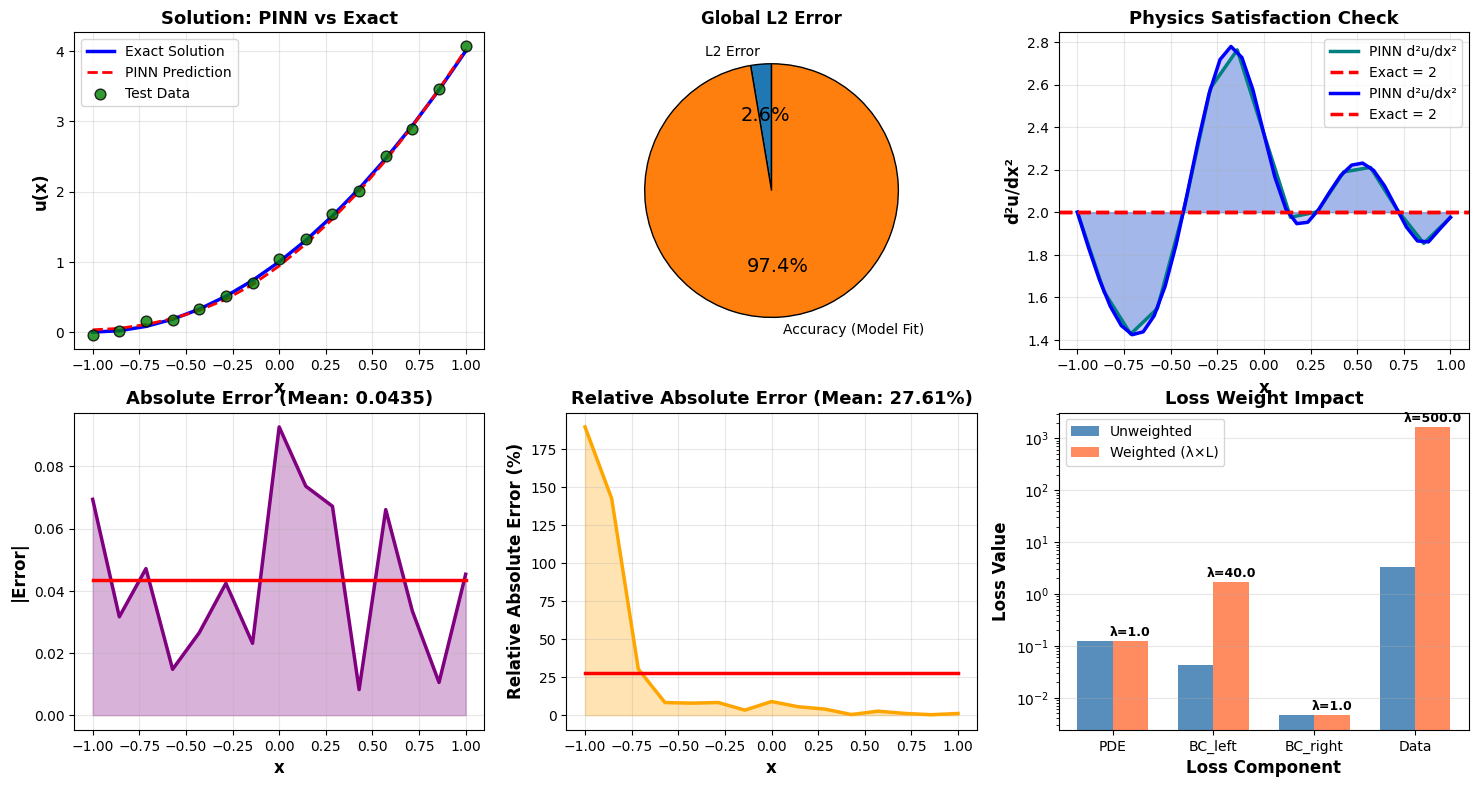

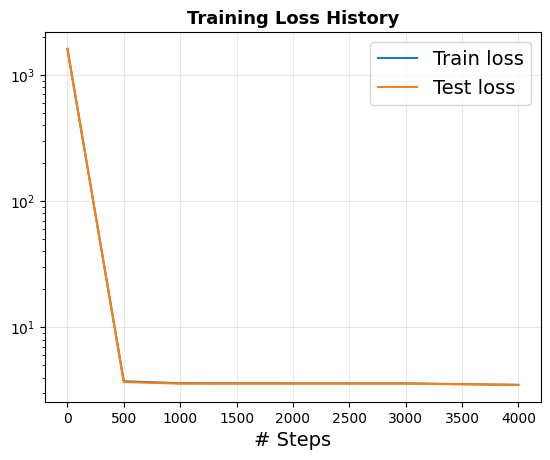

In [54]:

# 11. VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(18, 14))

# Plot 1: Solution Comparison
ax1 = plt.subplot(3, 3, 1)
plt.plot(x_test, y_exact, 'b-', linewidth=2.5, label='Exact Solution')
plt.plot(x_test, y_pred, 'r--', linewidth=2, label='PINN Prediction')
plt.scatter(x_test, y_test, c='green', s=60, 
            label='Test Data', zorder=5, alpha=0.8, edgecolors='black')
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('u(x)', fontsize=12, fontweight='bold')
plt.title('Solution: PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)





# -----------------------------------------------
# Plot 2: Global L2 Error Pie Chart
# -----------------------------------------------
ax2 = plt.subplot(3, 3, 2)

# Compute L2 error (%)
l2_error_pct = 100 * np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)

# Pie chart values
sizes = [l2_error_pct, 100 - l2_error_pct]
labels = [f'L2 Error', 'Accuracy (Model Fit)']

# Draw pie chart inside subplot
ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)

ax2.set_title('Global L2 Error', fontsize=12, fontweight='bold')

# VERY IMPORTANT so pie fits well inside subplot
ax2.set_aspect('equal')





# Plot 3: Physics Check
ax3 = plt.subplot(3, 3, 3)
d2u_dx2 = model.predict(
    x_test,
    operator=lambda x, y: dde.grad.hessian(y, x, i=0, j=0)
)
d2u_dx2_1 = model.predict(
    observe_x,
    operator=lambda x, y: dde.grad.hessian(y, x, i=0, j=0)
)
plt.plot(x_test, d2u_dx2, 'teal', linewidth=2.5, label='PINN d²u/dx²')
plt.axhline(y=2, color='red', linestyle='--', linewidth=2.5, label='Exact = 2')
plt.fill_between(x_test.flatten(), 2, d2u_dx2.flatten(), alpha=0.2, color='teal')
plt.plot(observe_x, d2u_dx2_1, 'blue', linewidth=2.5, label='PINN d²u/dx²')
plt.axhline(y=2, color='red', linestyle='--', linewidth=2.5, label='Exact = 2')
plt.fill_between(observe_x.flatten(), 2, d2u_dx2_1.flatten(), alpha=0.2, color='blue')
plt.xlabel('x', fontsize=12, fontweight='bold')

plt.ylabel('d²u/dx²', fontsize=12, fontweight='bold')
plt.title('Physics Satisfaction Check', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)





# Plot 4: Absolute Error
ax4 = plt.subplot(3, 3, 4)

# Absolute error curve
plt.plot(x_test, absolute_error, color='purple', linewidth=2.5)

# Mean absolute error line (constant horizontal line)
mean_abs_err = np.mean(absolute_error)
plt.plot(x_test, np.full_like(x_test, mean_abs_err), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, absolute_error.flatten(), alpha=0.3, color='purple')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('|Error|', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {np.mean(absolute_error):.4f})',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





# Plot 5: Relative Absolute Error
ax5 = plt.subplot(3, 3, 5)

# Relative absolute error curve (%)
plt.plot(x_test, relative_error * 100, color='orange', linewidth=2.5)

# Mean relative error line (horizontal)
mean_rel_err_pct = np.mean(relative_error) * 100
plt.plot(x_test, np.full_like(x_test, mean_rel_err_pct), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, (relative_error * 100).flatten(),
                 alpha=0.3, color='orange')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('Relative Absolute Error (%)', fontsize=12, fontweight='bold')
plt.title(f'Relative Absolute Error (Mean: {mean_rel_err_pct:.2f}%)',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





# Plot 6: Loss Weight Analysis (Correct & Compact)
ax6 = plt.subplot(3, 3, 6)

# Use actual final training losses from DeepXDE
losses = model.losshistory.loss_train[-1]          # [PDE, BC_left, BC_right, Data]
weighted = [w * l for w, l in zip(loss_weights, losses)]

components = ['PDE', 'BC_left', 'BC_right', 'Data']
x_pos = np.arange(len(components))
width = 0.35

ax6.bar(x_pos - width/2, losses,    width, label='Unweighted', alpha=0.9, color='steelblue')
ax6.bar(x_pos + width/2, weighted,  width, label='Weighted (λ×L)', alpha=0.9, color='coral')

ax6.set_xlabel('Loss Component', fontsize=12, fontweight='bold')
ax6.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax6.set_title('Loss Weight Impact', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(components)
ax6.set_yscale('log')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

# Annotate λ values on weighted bars
for bar, λ in zip(ax6.patches[len(components):], loss_weights):
    h = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2, h * 1.1, f'λ={λ}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')




# Plot 7: Loss History
dde.utils.plot_loss_history(losshistory)
plt.title('Training Loss History', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
